In [3]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns;

QUESTION 1:

In [4]:
# Step 1: Loading dataset as strings
raw_data = np.genfromtxt('India_Statewise_Power_Infrastructure_Data_RBI.csv', delimiter=',', dtype=str)

# Step 2: Removing header row
data_no_header = raw_data[1:, :]

# Step 3: Slicing numeric columns (skip first two)
numeric_data = data_no_header[:, 2:].copy()

# Step 4: Replacing "-" and "." with NaN
mask = (numeric_data == '-') | (numeric_data == '.')
numeric_data[mask] = 'nan'

# Step 5: Convert to float64 and float32
data_float64 = numeric_data.astype(np.float64)
data_float32 = numeric_data.astype(np.float32)

# Step 6: Compare memory usage
print("Memory usage (float64):", data_float64.nbytes, "bytes")
print("Memory usage (float32):", data_float32.nbytes, "bytes")

Memory usage (float64): 19584 bytes
Memory usage (float32): 9792 bytes


C:\Users\Proshita\AppData\Local\Temp\ipykernel_23280\992929875.py:16: RuntimeWarning: invalid value encountered in cast
  data_float32 = numeric_data.astype(np.float32)


QUESTION 2:

In [5]:
import numpy as np

# Step 1: Load dataset as strings
raw_data = np.genfromtxt('India_Statewise_Power_Infrastructure_Data_RBI.csv', delimiter=',', dtype=str)

# Step 2: Remove header row
data_no_header = raw_data[1:, :]

# Step 3: Extract columns
states = data_no_header[:, 0]
years = data_no_header[:, 1]
requirement = data_no_header[:, 2]
availability = data_no_header[:, 3]

# Step 4: Replace "-" and "." with "nan" (string)
requirement = np.where((requirement == '-') | (requirement == '.'), 'nan', requirement)
availability = np.where((availability == '-') | (availability == '.'), 'nan', availability)

# Step 5: Convert to float (strings "nan" -> np.nan automatically)
requirement = requirement.astype(np.float64)
availability = availability.astype(np.float64)

# Step 6: Get unique states and years (for reshaping)
unique_states = np.unique(states)
unique_years = np.unique(years)

# Step 7: Initialize 3D array (states × years × 2)
data_3d = np.full((len(unique_states), len(unique_years), 2), np.nan)

# Fill requirement (slice 0) and availability (slice 1)
for i, state in enumerate(unique_states):
    for j, year in enumerate(unique_years):
        mask = (states == state) & (years == year)
        if np.any(mask):
            data_3d[i, j, 0] = requirement[mask][0]
            data_3d[i, j, 1] = availability[mask][0]

# Step 8: Compute supply gap ratio without loops
# formula: (requirement - availability) / requirement
supply_gap_ratio = (data_3d[:, :, 0] - data_3d[:, :, 1]) / data_3d[:, :, 0]

print("Shape of 3D array:", data_3d.shape)
print("Supply gap ratio matrix:\n", supply_gap_ratio)


Shape of 3D array: (36, 17, 2)
Supply gap ratio matrix:
 [[            nan  2.91666667e-01  2.08333333e-01  2.50000000e-01
   2.50000000e-01  2.50000000e-01  2.50000000e-01  1.66666667e-01
   2.08333333e-01  2.50000000e-01  2.50000000e-01  2.50000000e-01
   2.50000000e-01  9.09090909e-02  8.57142857e-02  8.57142857e-02
   8.57142857e-02]
 [ 7.14002380e-03  1.32000754e-02  4.39632546e-02  4.10040536e-02
   6.76828416e-02  6.62025316e-02  3.19108522e-02  7.17322577e-02
   1.75744809e-01  6.92034288e-02  4.88175676e-02  1.38778747e-03
   7.36648250e-04  1.54162384e-03 -9.41324129e-04  6.11153552e-04
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.03448276e-01  2.30769231e-01
   3.72093023e-01  1.75000000e-01  1.37254902e-01  8.33333333e-02
   6.77966102e-02  5.45454545e-02  1.02941176e-01  6.34920635e-02
   2.73972603e-02  1.25000000e-02  0.00000000e+00  0.00000000e+00
   1.38888889e-02]
 [ 5.54089710e-02  6.66666667e-02  7.44186047e-02  8.50622407e-02
   1.05675147e-01  8.3984375

QUESTION 3:

In [6]:
# Step 1: Load dataset
raw_data = np.genfromtxt("India_Statewise_Power_Infrastructure_Data_RBI.csv",
                         delimiter=",", dtype=str)

# Step 2: Remove header row
data_no_header = raw_data[1:, :]

# Extract columns
states = data_no_header[:, 0]
years = data_no_header[:, 1]
installed_capacity = data_no_header[:, 5]   # Installed Power Capacity (MW)

# Step 3: Replace "-" and "." with NaN
installed_capacity = np.where(np.isin(installed_capacity, ['-', '.']), 'nan', installed_capacity)

# Step 4: Convert to float
installed_capacity = installed_capacity.astype(np.float64)

# Step 5: Unique states & years
unique_states = np.unique(states)
unique_years = np.unique(years)

# Step 6: Reshape into (states × years) grid
capacity_matrix = np.full((len(unique_states), len(unique_years)), np.nan)

for i, state in enumerate(unique_states):
    for j, year in enumerate(unique_years):
        mask = (states == state) & (years == year)
        if np.any(mask):
            capacity_matrix[i, j] = installed_capacity[mask][0]

# Step 7: Normalize per year using broadcasting
# (subtract column mean, divide by column std)
year_means = np.nanmean(capacity_matrix, axis=0, keepdims=True)
year_stds = np.nanstd(capacity_matrix, axis=0, keepdims=True)

z_scores = (capacity_matrix - year_means) / year_stds

# Step 8: Find top-5 outlier states by z-score magnitude
# (take absolute z-score, then max across years per state)
max_abs_z = np.nanmax(np.abs(z_scores), axis=1)

top5_idx = np.argsort(max_abs_z)[-5:][::-1]   # indices of top-5
top5_states = unique_states[top5_idx]
top5_scores = max_abs_z[top5_idx]

print("Top-5 outlier states by z-score magnitude:")
for state, score in zip(top5_states, top5_scores):
    print(f"{state}: {score:.2f}")


Top-5 outlier states by z-score magnitude:
Maharashtra: 3.50
Gujarat: 2.65
Tamil Nadu: 2.15
Andhra Pradesh: 1.92
Karnataka: 1.65


QUESTION 4:

In [7]:
# Step 1: Load dataset
raw_data = np.genfromtxt("India_Statewise_Power_Infrastructure_Data_RBI.csv",
                         delimiter=",", dtype=str)

# Step 2: Remove header
data_no_header = raw_data[1:, :]

# Extract columns
states = data_no_header[:, 0]
years = data_no_header[:, 1]
percap_avail = data_no_header[:, 4]   # Availability of Power Per Capita (kWh)

# Step 3: Replace "-" and "." with NaN
percap_avail = np.where(np.isin(percap_avail, ['-', '.']), 'nan', percap_avail)

# Step 4: Convert to float
percap_avail = percap_avail.astype(np.float64)

# Step 5: Unique states & years
unique_states = np.unique(states)
unique_years = np.unique(years)

# Step 6: Reshape into (states × years) grid
percap_matrix = np.full((len(unique_states), len(unique_years)), np.nan)

for i, state in enumerate(unique_states):
    for j, year in enumerate(unique_years):
        mask = (states == state) & (years == year)
        if np.any(mask):
            percap_matrix[i, j] = percap_avail[mask][0]

# Step 7: Compute YoY growth (vectorized)
# Formula: (current - previous) / previous
growth_rate = (percap_matrix[:, 1:] - percap_matrix[:, :-1]) / percap_matrix[:, :-1]

print("Shape of growth rate matrix:", growth_rate.shape)  # (states × (years-1))
print("YoY growth (first 5 states, first 5 years):\n", growth_rate[:5, :5])


Shape of growth rate matrix: (36, 16)
YoY growth (first 5 states, first 5 years):
 [[        nan  0.14460416 -0.05267104  0.02216066 -0.02168022]
 [ 0.04536459  0.11358672  0.05544658  0.08400446  0.10629786]
 [ 0.30368311  0.25746269  0.16617211 -0.10287168  0.1993517 ]
 [ 0.05431548  0.05504587  0.10702341  0.03504532  0.02685347]
 [ 0.11538462  0.07241379  0.02465166  0.10878661  0.12641509]]


QUESTION 5:

In [8]:
# Step 1: Load dataset
df = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")

# Step 2: Identify numeric columns (all except State & Year)
numeric_cols = df.columns[2:]

# Step 3: Convert numeric columns to float, forcing errors -> NaN
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Step 4: Convert Year to datetime (take only starting year, e.g. "2004-05" → 2004)
df['Year'] = df['Year'].astype(str).str[:4]   # keep first 4 chars
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Step 5: Report missing values per column
print("Missing values per column:")
print(df.isna().sum())

# Step 6: Report missing values per state
missing_per_state = df.groupby("State/Union Territory").apply(lambda g: g.isna().sum())
print("\nMissing values per state:")
print(missing_per_state)


Missing values per column:
State/Union Territory                              0
Year                                               0
Power_Requirement_Net_Crore_Units                 13
Availability_Of_Power_Net_Crore_Units             13
Availability_Of_Power_Per_Capita_kiloWatt-Hour    13
Installed_Power_Capacity_MegaWatt                 10
dtype: int64

Missing values per state:
                             State/Union Territory  Year  \
State/Union Territory                                      
Andaman and Nicobar Islands                      0     0   
Andhra Pradesh                                   0     0   
Arunachal Pradesh                                0     0   
Assam                                            0     0   
Bihar                                            0     0   
Chandigarh                                       0     0   
Chhattisgarh                                     0     0   
Dadra and Nagar Haveli                           0     0   
Daman and Diu  

C:\Users\Proshita\AppData\Local\Temp\ipykernel_23280\1079932548.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_per_state = df.groupby("State/Union Territory").apply(lambda g: g.isna().sum())


QUESTION 6:

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")

# Clean column names: lowercase + strip spaces
df.columns = df.columns.str.strip().str.lower()

# Detect installed capacity column automatically
capacity_col = [c for c in df.columns if "installed" in c][0]

# Convert to numeric
df[capacity_col] = pd.to_numeric(df[capacity_col], errors="coerce")

# Clean Year column (keep only first 4 digits)
df["year"] = df["year"].astype(str).str[:4].astype(int)

# Sort values
df = df.sort_values(["state/union territory", "year"])

# Compute year-to-year difference
df["diff"] = df.groupby("state/union territory")[capacity_col].diff()
df["growth"] = df["diff"] > 0

# Function to compute longest growth streak
def longest_growth_streak(series):
    streak = max_streak = 0
    for val in series:
        if val:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

# Apply per state
growth_streaks = df.groupby("state/union territory")["growth"].apply(longest_growth_streak)

# Filter states with ≥5 consecutive years of growth
states_with_growth = growth_streaks[growth_streaks >= 5].index.tolist()

print("States with >=5 consecutive years of growth in installed capacity:")
print(states_with_growth)

States with >=5 consecutive years of growth in installed capacity:
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


QUESTION 7:

In [12]:
# Reload dataset (only needed if df_power not in memory)
df_power = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")
df_power.columns = df_power.columns.str.strip()

# Detect required columns dynamically
state_col = [c for c in df_power.columns if "state" in c.lower()][0]
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
req_col = [c for c in df_power.columns if "requirement" in c.lower()][0]
avail_col = [c for c in df_power.columns if "availability" in c.lower() and "net" in c.lower()][0]

# Convert types
df_power[req_col] = pd.to_numeric(df_power[req_col], errors="coerce")
df_power[avail_col] = pd.to_numeric(df_power[avail_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

# Region mapping (same as used earlier)
region_map = {
    "Delhi": "North", "Haryana": "North", "Punjab": "North", "Uttar Pradesh": "North",
    "Rajasthan": "North", "Himachal Pradesh": "North", "Jammu & Kashmir": "North",
    "Uttarakhand": "North", "Chandigarh": "North",
    "Maharashtra": "West", "Gujarat": "West", "Goa": "West",
    "Daman & Diu": "West", "Dadra & Nagar Haveli": "West",
    "Karnataka": "South", "Kerala": "South", "Tamil Nadu": "South",
    "Andhra Pradesh": "South", "Telangana": "South", "Puducherry": "South",
    "Odisha": "East", "West Bengal": "East", "Bihar": "East", "Jharkhand": "East",
    "Sikkim": "East", "Assam": "East", "Arunachal Pradesh": "East",
    "Nagaland": "East", "Manipur": "East", "Mizoram": "East",
    "Meghalaya": "East", "Tripura": "East"
}

# Add Region column
df_power["Region"] = df_power[state_col].map(region_map)

# Compute supply gap ratio
df_power["supply_gap_ratio"] = (df_power[req_col] - df_power[avail_col]) / df_power[req_col]

# Group by Region-Year
region_year = df_power.groupby(["Region", year_col], as_index=False)["supply_gap_ratio"].mean()

# Rolling mean & std (5 years per region)
region_year["rolling_mean"] = region_year.groupby("Region")["supply_gap_ratio"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
region_year["rolling_std"] = region_year.groupby("Region")["supply_gap_ratio"].transform(
    lambda x: x.rolling(5, min_periods=1).std()
)

# Region with highest volatility
volatility = region_year.groupby("Region")["rolling_std"].mean().sort_values(ascending=False)

display(region_year.head(10))  # preview
print("\nRegion with highest volatility in supply gap ratio:")
print(volatility.index[0], "→", volatility.iloc[0])

,Region,Year,supply_gap_ratio,rolling_mean,rolling_std
0,East,2004,0.049014,0.049014,NaN
1,East,2005,0.053482,0.051248,0.003159
2,East,2006,0.068337,0.056944,0.010116
3,East,2007,0.115898,0.071683,0.030612
4,East,2008,0.120652,0.081477,0.034386
5,East,2009,0.110436,0.093761,0.030660
6,East,2010,0.078988,0.098862,0.023589
7,East,2011,0.083906,0.101976,0.019165
8,East,2012,0.061281,0.091053,0.024160
9,East,2013,0.040300,0.074982,0.026188



Region with highest volatility in supply gap ratio:
South → 0.02128283729277905


QUESTION 8:

In [13]:
# Load dataset
df = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")

# Clean column names
df.columns = df.columns.str.strip()

# --- Detect columns dynamically ---
# Requirement column (first match containing "Requirement")
req_col = [c for c in df.columns if "Requirement" in c][0]

# Availability column (must contain both "Availability" and "Net")
avail_col = [c for c in df.columns if "Availability" in c and "Net" in c][0]

# Year column
year_col = [c for c in df.columns if "Year" in c][0]

# State column
state_col = [c for c in df.columns if "State" in c][0]

print("Detected columns →", req_col, "|", avail_col, "|", year_col, "|", state_col)

# Convert numeric columns
df[req_col] = pd.to_numeric(df[req_col], errors='coerce')
df[avail_col] = pd.to_numeric(df[avail_col], errors='coerce')

# Clean Year (take first 4 digits → int)
df[year_col] = df[year_col].astype(str).str[:4].astype(int)

# --- Region mapping ---
region_map = {
    # North
    "Delhi": "North", "Haryana": "North", "Punjab": "North", "Uttar Pradesh": "North",
    "Rajasthan": "North", "Himachal Pradesh": "North", "Jammu & Kashmir": "North",
    "Uttarakhand": "North", "Chandigarh": "North",

    # West
    "Maharashtra": "West", "Gujarat": "West", "Goa": "West",
    "Daman & Diu": "West", "Dadra & Nagar Haveli": "West",

    # South
    "Karnataka": "South", "Kerala": "South", "Tamil Nadu": "South",
    "Andhra Pradesh": "South", "Telangana": "South", "Puducherry": "South",

    # East (including NE)
    "Odisha": "East", "West Bengal": "East", "Bihar": "East", "Jharkhand": "East",
    "Sikkim": "East", "Assam": "East", "Arunachal Pradesh": "East",
    "Nagaland": "East", "Manipur": "East", "Mizoram": "East",
    "Meghalaya": "East", "Tripura": "East"
}

df["Region"] = df[state_col].map(region_map)

# --- Supply gap ratio ---
df["supply_gap_ratio"] = (df[req_col] - df[avail_col]) / df[req_col]

# Group by Region-Year
region_year = df.groupby(["Region", year_col], as_index=False)["supply_gap_ratio"].mean()

# Rolling mean & std (5 years)
region_year["rolling_mean"] = region_year.groupby("Region")["supply_gap_ratio"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
region_year["rolling_std"] = region_year.groupby("Region")["supply_gap_ratio"].transform(
    lambda x: x.rolling(5, min_periods=1).std()
)

# --- Find most volatile region ---
volatility = region_year.groupby("Region")["rolling_std"].mean().sort_values(ascending=False)

print("\n5-year rolling results (sample):")
print(region_year.head(10))

print("\nMost volatile region in supply gap ratio:")
print(volatility.index[0], "→", volatility.iloc[0])

Detected columns → Power_Requirement_Net_Crore_Units | Availability_Of_Power_Net_Crore_Units | Year | State/Union Territory

5-year rolling results (sample):
  Region  Year  supply_gap_ratio  rolling_mean  rolling_std
0   East  2004          0.049014      0.049014          NaN
1   East  2005          0.053482      0.051248     0.003159
2   East  2006          0.068337      0.056944     0.010116
3   East  2007          0.115898      0.071683     0.030612
4   East  2008          0.120652      0.081477     0.034386
5   East  2009          0.110436      0.093761     0.030660
6   East  2010          0.078988      0.098862     0.023589
7   East  2011          0.083906      0.101976     0.019165
8   East  2012          0.061281      0.091053     0.024160
9   East  2013          0.040300      0.074982     0.026188

Most volatile region in supply gap ratio:
South → 0.02128283729277905


QUESTION 9:

In [14]:
df = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")
df.columns = df.columns.str.strip()  # clean spaces

# Detect columns dynamically using lowercase search
state_col   = [c for c in df.columns if "state" in c.lower()][0]
year_col    = [c for c in df.columns if "year" in c.lower()][0]
percap_col  = [c for c in df.columns if "per" in c.lower() and "capita" in c.lower()][0]

print("Detected columns →", state_col, "|", year_col, "|", percap_col)

# Convert numeric
df[percap_col] = pd.to_numeric(df[percap_col], errors='coerce')

# Clean year (first 4 digits)
df[year_col] = df[year_col].astype(str).str[:4].astype(int)

# Pivot (states × years)
pivot_df = df.pivot(index=state_col, columns=year_col, values=percap_col)

print("\nPivot table (sample):")
print(pivot_df.head())

# Melt back to long format
melt_df = pivot_df.reset_index().melt(id_vars=state_col, var_name="Year", value_name="PerCapitaAvailability")
print("\nMelted DataFrame (sample):")
print(melt_df.head())

# Compute increase (last - first year) per state
increase = pivot_df.apply(lambda row: row.iloc[-1] - row.iloc[0], axis=1)

# State with steepest increase
top_state = increase.idxmax()
top_increase = increase.max()

print(f"\nState with steepest increase in per-capita availability: {top_state} ({top_increase:.2f})")

Detected columns → State/Union Territory | Year | Availability_Of_Power_Per_Capita_kiloWatt-Hour

Pivot table (sample):
Year                          2004   2005   2006   2007   2008   2009    2010  \
State/Union Territory                                                           
Andaman and Nicobar Islands    NaN  466.1  533.5  505.4  516.6  505.4   505.4   
Andhra Pradesh               656.9  686.7  764.7  807.1  874.9  967.9  1003.1   
Arunachal Pradesh            143.9  187.6  235.9  275.1  246.8  296.0   397.1   
Assam                        134.4  141.7  149.5  165.5  171.3  175.9   189.9   
Bihar                         78.0   87.0   93.3   95.6  106.0  119.4   129.8   

Year                           2011   2012    2013    2014    2015    2016  \
State/Union Territory                                                        
Andaman and Nicobar Islands   536.9  489.5   473.8   473.8   473.8   473.8   
Andhra Pradesh               1005.7  970.5  1051.6  1140.2  1019.8  1098.6   


QUESTION 10:

In [15]:
# Step 1: Load datasets
df_power = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")
df_pop = pd.read_csv("census_2011.csv")

# Step 2: Clean column names
df_power.columns = df_power.columns.str.strip()
df_pop.columns = df_pop.columns.str.strip()

# Detect key columns dynamically
state_col_power = [c for c in df_power.columns if "state" in c.lower()][0]
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
capacity_col = [c for c in df_power.columns if "installed" in c.lower()][0]

state_col_pop = [c for c in df_pop.columns if "state" in c.lower()][0]
pop_col = [c for c in df_pop.columns if "population" in c.lower()][0]

print("Detected:", state_col_power, "|", year_col, "|", capacity_col)
print("Census:", state_col_pop, "|", pop_col)

# Step 3: Convert numeric columns
df_power[capacity_col] = pd.to_numeric(df_power[capacity_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

df_pop[pop_col] = pd.to_numeric(df_pop[pop_col], errors="coerce")

# Step 4: Merge with Census population
df_merged = df_power.merge(df_pop, left_on=state_col_power, right_on=state_col_pop, how="inner")

# Step 5: Installed capacity per million population
df_merged["capacity_per_million"] = (df_merged[capacity_col] / df_merged[pop_col]) * 1_000_000

# Step 6: Compute CAGR per state
cagr_results = []
for state, g in df_merged.groupby(state_col_power):
    g = g.sort_values(year_col)
    start_val = g.loc[g[year_col] == g[year_col].min(), "capacity_per_million"].values
    end_val = g.loc[g[year_col] == g[year_col].max(), "capacity_per_million"].values
    
    if len(start_val) > 0 and len(end_val) > 0 and start_val[0] > 0:
        n_years = g[year_col].max() - g[year_col].min()
        cagr = (end_val[0] / start_val[0])**(1/n_years) - 1
        cagr_results.append((state, cagr))

df_cagr = pd.DataFrame(cagr_results, columns=["State", "CAGR"]).sort_values("CAGR", ascending=False)

print("\nInstalled capacity per million population (sample):")
print(df_merged[[state_col_power, year_col, "capacity_per_million"]].head())

print("\nTop states by CAGR (2004–2020):")
print(df_cagr.head(10))


Detected: State/Union Territory | Year | Installed_Power_Capacity_MegaWatt
Census: State name | Population

Installed capacity per million population (sample):
Empty DataFrame
Columns: [State/Union Territory, Year, capacity_per_million]
Index: []

Top states by CAGR (2004–2020):
Empty DataFrame
Columns: [State, CAGR]
Index: []


QUESTION 11:

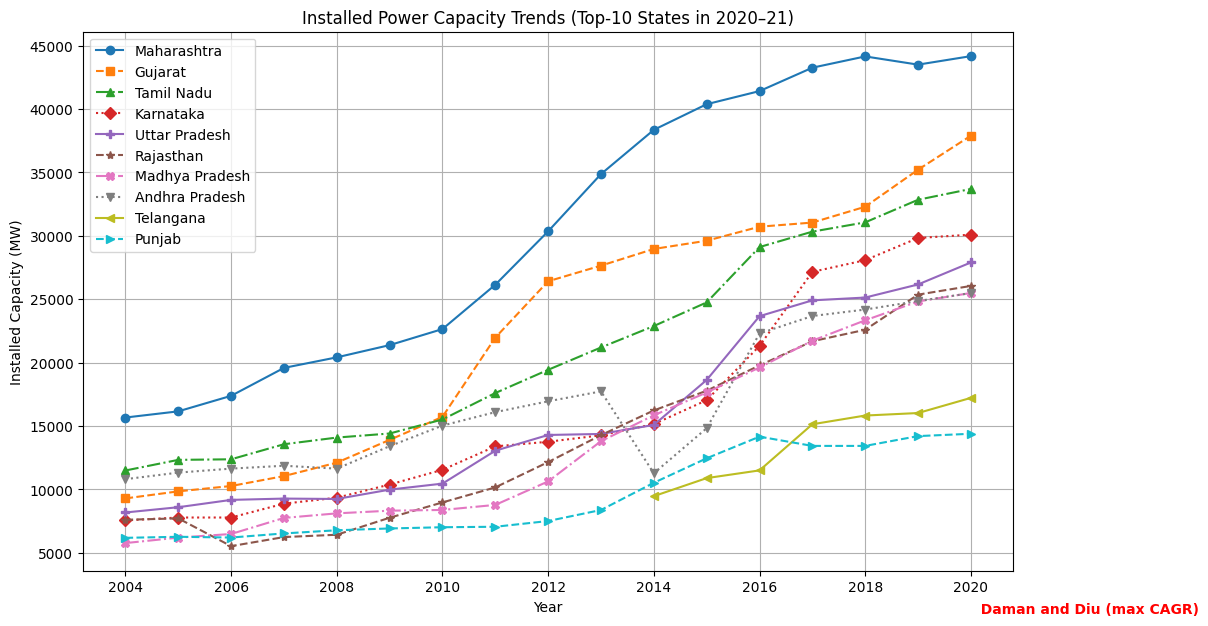

In [16]:
# Step 1: Load dataset
df_power = pd.read_csv("India_Statewise_Power_Infrastructure_Data_RBI.csv")
df_power.columns = df_power.columns.str.strip()

# Detect columns dynamically
state_col = [c for c in df_power.columns if "state" in c.lower()][0]
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
capacity_col = [c for c in df_power.columns if "installed" in c.lower()][0]

# Step 2: Convert dtypes
df_power[capacity_col] = pd.to_numeric(df_power[capacity_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

# Step 3: Get top-10 states by installed capacity in latest year (2020/2021)
latest_year = df_power[year_col].max()
top_states = (
    df_power[df_power[year_col] == latest_year]
    .nlargest(10, capacity_col)[state_col]
    .tolist()
)

# Step 4: Compute CAGR again (to annotate later)
cagr_results = []
for state, g in df_power.groupby(state_col):
    g = g.sort_values(year_col)
    start_val = g.loc[g[year_col] == g[year_col].min(), capacity_col].values
    end_val = g.loc[g[year_col] == g[year_col].max(), capacity_col].values
    if len(start_val) > 0 and len(end_val) > 0 and start_val[0] > 0:
        n_years = g[year_col].max() - g[year_col].min()
        cagr = (end_val[0] / start_val[0])**(1/n_years) - 1
        cagr_results.append((state, cagr))

df_cagr = pd.DataFrame(cagr_results, columns=["State", "CAGR"]).sort_values("CAGR", ascending=False)
top_cagr_state = df_cagr.iloc[0]["State"]
top_cagr_value = df_cagr.iloc[0]["CAGR"]

# Step 5: Plot trends for top-10 states
plt.figure(figsize=(12, 7))

styles = ['-', '--', '-.', ':']   # cycle line styles
markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v', '<', '>']

for i, state in enumerate(top_states):
    g = df_power[df_power[state_col] == state].sort_values(year_col)
    plt.plot(
        g[year_col], g[capacity_col],
        linestyle=styles[i % len(styles)],
        marker=markers[i % len(markers)],
        label=state
    )

# Step 6: Annotate state with max CAGR
g = df_power[df_power[state_col] == top_cagr_state].sort_values(year_col)
plt.text(
    g[year_col].iloc[-1], g[capacity_col].iloc[-1],
    f"  {top_cagr_state} (max CAGR)",
    fontsize=10, fontweight="bold", color="red"
)

# Step 7: Labels & legend
plt.title("Installed Power Capacity Trends (Top-10 States in 2020–21)")
plt.xlabel("Year")
plt.ylabel("Installed Capacity (MW)")
plt.legend()
plt.grid(True)
plt.show()


QUESTION 12:

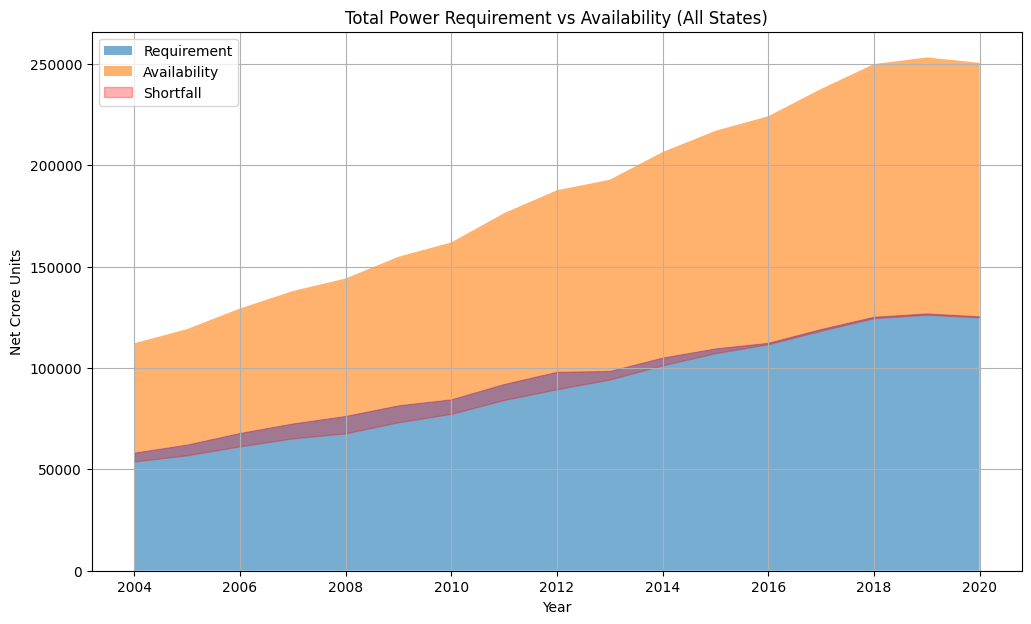

In [17]:
# Clean column names
df_power.columns = df_power.columns.str.strip()

# Detect columns dynamically
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
req_col = [c for c in df_power.columns if "requirement" in c.lower()][0]
avail_col = [c for c in df_power.columns if "availability" in c.lower() and "net" in c.lower()][0]

# Convert numeric
df_power[req_col] = pd.to_numeric(df_power[req_col], errors="coerce")
df_power[avail_col] = pd.to_numeric(df_power[avail_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

# Aggregate totals across all states per year
national = df_power.groupby(year_col)[[req_col, avail_col]].sum().reset_index()

# Plot stacked area
plt.figure(figsize=(12, 7))
plt.stackplot(national[year_col],
              national[req_col],
              national[avail_col],
              labels=["Requirement", "Availability"],
              alpha=0.6)

# Shade the shortfall (gap region)
plt.fill_between(
    national[year_col],
    national[avail_col],
    national[req_col],
    where=(national[req_col] > national[avail_col]),
    color="red",
    alpha=0.3,
    interpolate=True,
    label="Shortfall"
)

plt.title("Total Power Requirement vs Availability (All States)")
plt.xlabel("Year")
plt.ylabel("Net Crore Units")
plt.legend()
plt.grid(True)
plt.show()


QUESTION 13:

C:\Users\Proshita\AppData\Local\Temp\ipykernel_23280\3903299851.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_latest["Region"] = df_latest[state_col].map(region_map)


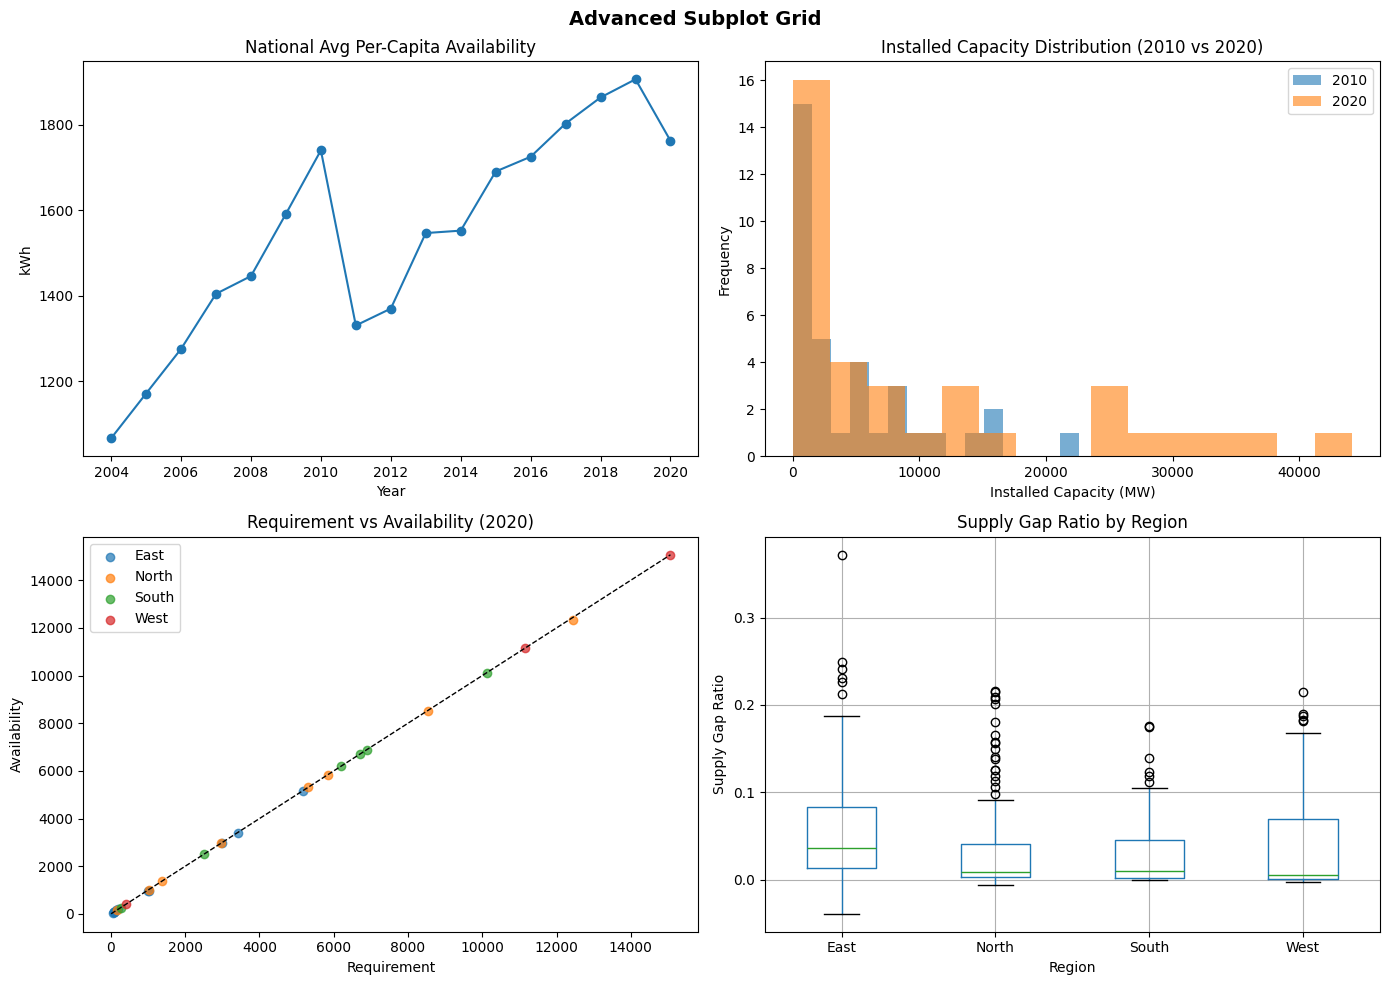

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Detect needed columns dynamically
state_col = [c for c in df_power.columns if "state" in c.lower()][0]
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
req_col = [c for c in df_power.columns if "requirement" in c.lower()][0]
avail_col = [c for c in df_power.columns if "availability" in c.lower() and "net" in c.lower()][0]
percap_col = [c for c in df_power.columns if "capita" in c.lower()][0]
capacity_col = [c for c in df_power.columns if "installed" in c.lower()][0]

# Ensure numeric types
df_power[req_col] = pd.to_numeric(df_power[req_col], errors="coerce")
df_power[avail_col] = pd.to_numeric(df_power[avail_col], errors="coerce")
df_power[percap_col] = pd.to_numeric(df_power[percap_col], errors="coerce")
df_power[capacity_col] = pd.to_numeric(df_power[capacity_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

#(a) National avg per-capita availability trend
nat_avg = df_power.groupby(year_col)[percap_col].mean().reset_index()
axes[0, 0].plot(nat_avg[year_col], nat_avg[percap_col], marker='o')
axes[0, 0].set_title("National Avg Per-Capita Availability")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("kWh")

#(b) Histogram of installed capacity (2010 vs 2020)
df_2010 = df_power[df_power[year_col] == 2010][capacity_col].dropna()
df_2020 = df_power[df_power[year_col] == 2020][capacity_col].dropna()

axes[0, 1].hist(df_2010, bins=15, alpha=0.6, label="2010")
axes[0, 1].hist(df_2020, bins=15, alpha=0.6, label="2020")
axes[0, 1].set_title("Installed Capacity Distribution (2010 vs 2020)")
axes[0, 1].set_xlabel("Installed Capacity (MW)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# (c) Scatter Requirement vs Availability (2020)
df_latest = df_power[df_power[year_col] == 2020]

# Map regions (reuse region_map from Q7)
df_latest["Region"] = df_latest[state_col].map(region_map)

for region, g in df_latest.groupby("Region"):
    axes[1, 0].scatter(g[req_col], g[avail_col], label=region, alpha=0.7)

axes[1, 0].plot([df_latest[req_col].min(), df_latest[req_col].max()],
                [df_latest[req_col].min(), df_latest[req_col].max()],
                color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Requirement vs Availability (2020)")
axes[1, 0].set_xlabel("Requirement")
axes[1, 0].set_ylabel("Availability")
axes[1, 0].legend()

#(d) Boxplot of supply gap ratio by region
df_power["supply_gap_ratio"] = (df_power[req_col] - df_power[avail_col]) / df_power[req_col]
df_power["Region"] = df_power[state_col].map(region_map)

df_power.boxplot(column="supply_gap_ratio", by="Region", ax=axes[1, 1])
axes[1, 1].set_title("Supply Gap Ratio by Region")
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("Supply Gap Ratio")

# Fix subplot layout
plt.suptitle("Advanced Subplot Grid", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


QUESTION 14:

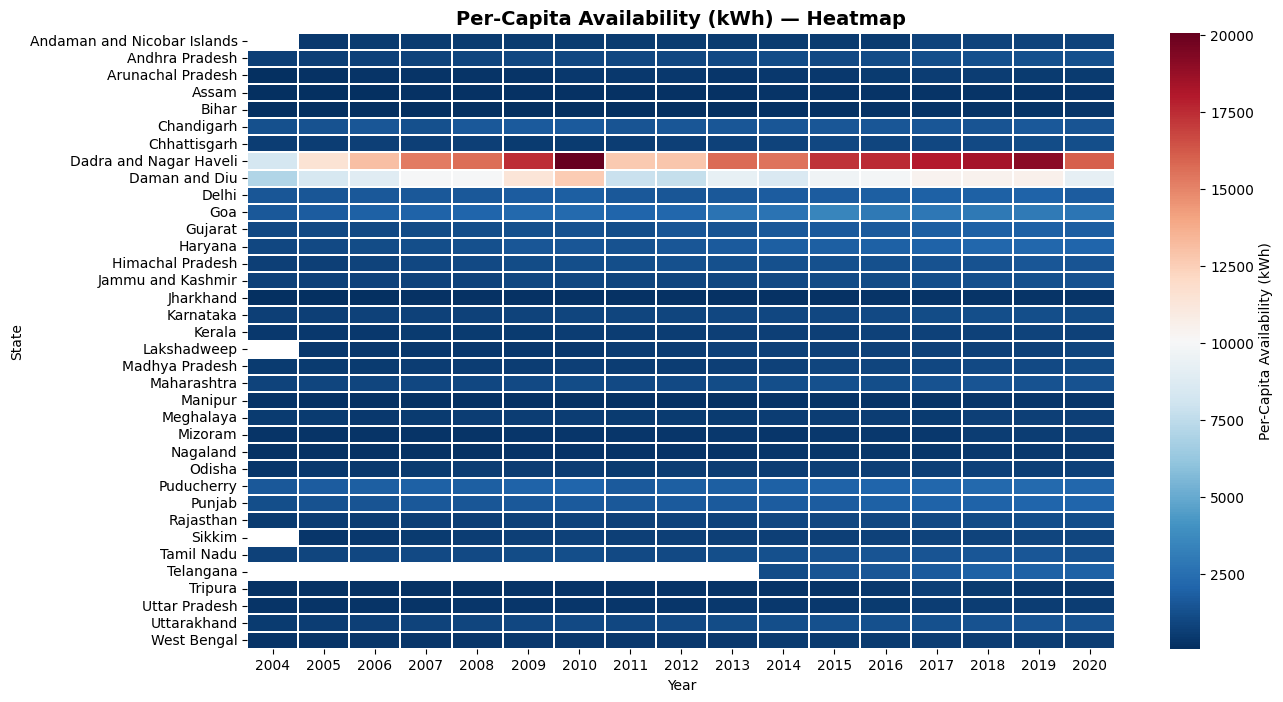

In [19]:
# Detect columns dynamically
state_col = [c for c in df_power.columns if "state" in c.lower()][0]
year_col = [c for c in df_power.columns if "year" in c.lower()][0]
percap_col = [c for c in df_power.columns if "capita" in c.lower()][0]

# Ensure numeric
df_power[percap_col] = pd.to_numeric(df_power[percap_col], errors="coerce")
df_power[year_col] = df_power[year_col].astype(str).str[:4].astype(int)

# Pivot to state × year
heatmap_data = df_power.pivot(index=state_col, columns=year_col, values=percap_col)

# Plot heatmap (no clustering)
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",    # diverging colormap
    linewidths=0.2,
    annot=False,
    cbar_kws={'label': 'Per-Capita Availability (kWh)'}
)
plt.title("Per-Capita Availability (kWh) — Heatmap", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

QUESTION 15:

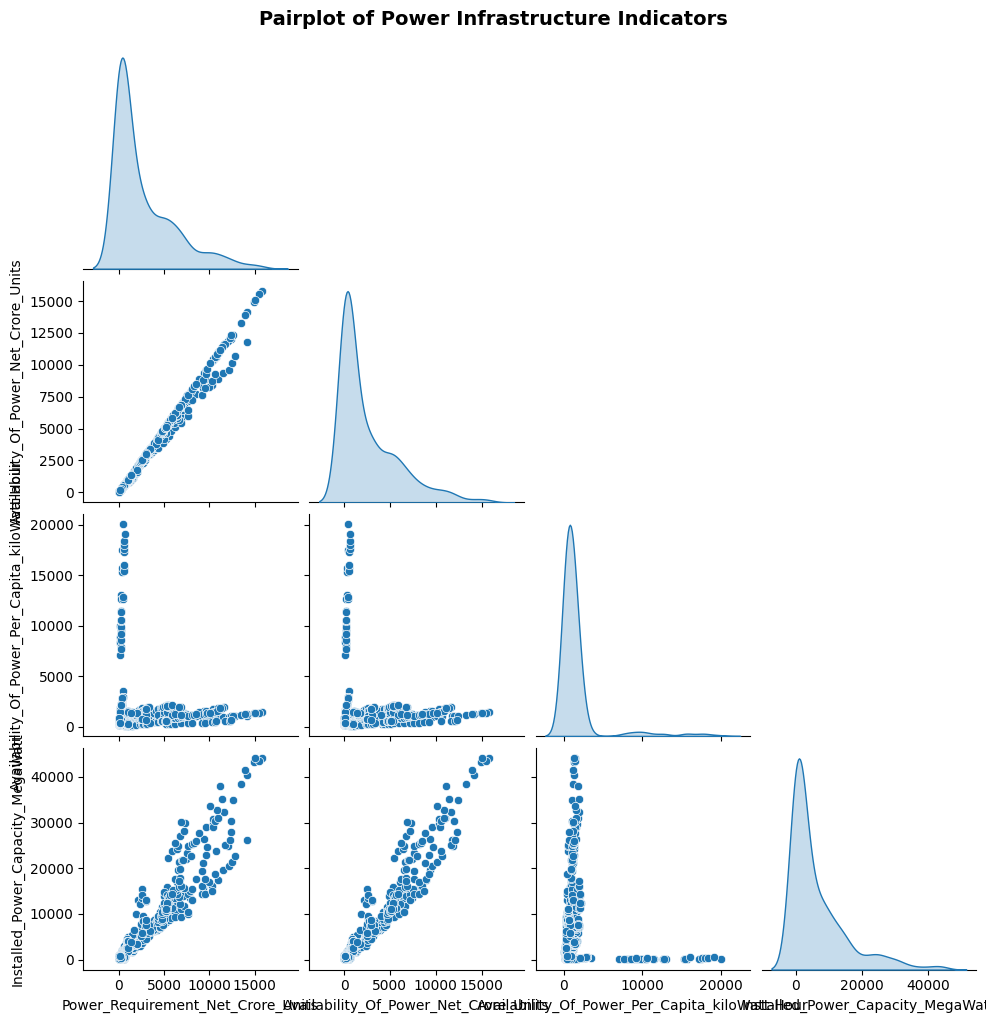

Correlation matrix:
                                                 Power_Requirement_Net_Crore_Units  \
Power_Requirement_Net_Crore_Units                                        1.000000   
Availability_Of_Power_Net_Crore_Units                                    0.995826   
Availability_Of_Power_Per_Capita_kiloWatt-Hour                          -0.106575   
Installed_Power_Capacity_MegaWatt                                        0.945922   

                                                Availability_Of_Power_Net_Crore_Units  \
Power_Requirement_Net_Crore_Units                                            0.995826   
Availability_Of_Power_Net_Crore_Units                                        1.000000   
Availability_Of_Power_Per_Capita_kiloWatt-Hour                              -0.102097   
Installed_Power_Capacity_MegaWatt                                            0.962692   

                                                Availability_Of_Power_Per_Capita_kiloWatt-Hour  \
Power_Req

In [ ]:
# Select the four numeric indicators
numeric_cols = [
    req_col,        # Power Requirement
    avail_col,      # Availability
    percap_col,     # Per-capita availability
    capacity_col    # Installed capacity
]

# Pairplot
sns.pairplot(df_power[numeric_cols].dropna(), diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Power Infrastructure Indicators", y=1.02, fontsize=14, fontweight="bold")
plt.show()

# Correlation matrix (to support strongest relationship)
corr_matrix = df_power[numeric_cols].corr(method="pearson")
print("Correlation matrix:\n", corr_matrix)

# Identify strongest non-linear trend manually by looking at scatterplots
# (Usually requirement vs availability is close to linear, but per-capita vs installed capacity may show non-linear)

NOTE: I wrote most of the code and the logic by myself but at times when it showed error i used gpt to debug it and then used that code here.